# 2.2 — Baseline ANN (TensorFlow/Keras)

Reproduz a ANN do REF1: 2 camadas ocultas × 8 neurônios, ativação ReLU, 1 saída linear, optimizer Adam, loss MSE.  
Uma rede por output — 3 runs no experimento `baseline`.

## Seção 1 — Imports e configuração

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

BASE_DIR    = "/Users/lorenzoferreira/Documents/UFRGS/TCC_SBO"
PROC_DIR    = os.path.join(BASE_DIR, "ARTEFATOS", "ETAPA_0", "processed")
ART_DIR     = os.path.join(BASE_DIR, "ARTEFATOS", "ETAPA_2", "ANN")
MLFLOW_URI  = f"file:///{BASE_DIR}/mlruns"

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment("baseline")

print("TensorFlow:", tf.__version__)
print("MLflow URI:", MLFLOW_URI)

TensorFlow: 2.21.0
MLflow URI: file:////Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/mlruns


## Seção 2 — Carga dos dados pré-processados

In [2]:
X_train = np.load(os.path.join(PROC_DIR, "X_train.npy"))
X_val   = np.load(os.path.join(PROC_DIR, "X_val.npy"))
X_test  = np.load(os.path.join(PROC_DIR, "X_test.npy"))

y_train = np.load(os.path.join(PROC_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(PROC_DIR, "y_val.npy"))
y_test  = np.load(os.path.join(PROC_DIR, "y_test.npy"))

scaler_y_min   = np.load(os.path.join(PROC_DIR, "scaler_y_min.npy"))
scaler_y_scale = np.load(os.path.join(PROC_DIR, "scaler_y_scale.npy"))

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_val:",   y_val.shape,   "| y_test:", y_test.shape)

OUTPUT_NAMES = ["M_CH3OH", "x_CH3OH", "ET"]

def denormalize_y(y_norm, idx):
    return y_norm * scaler_y_scale[idx] + scaler_y_min[idx]

X_train: (1536, 8) | X_val: (385, 8) | X_test: (193, 8)
y_train: (1536, 3) | y_val: (385, 3) | y_test: (193, 3)


## Seção 3 — Definição da arquitetura

In [3]:
def build_model(input_dim=8):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(8, activation="relu"),
        layers.Dense(8, activation="relu"),
        layers.Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

build_model().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153 (612.00 B)

 Trainable params: 153 (612.00 B)

 Non-trainable params: 0 (0.00 B)

## Seção 4 — Loop de treinamento

In [4]:
histories = {}
results   = []

for idx, output_name in enumerate(OUTPUT_NAMES):
    print(f"\n{'='*50}")
    print(f"Treinando ANN → {output_name}")
    print(f"{'='*50}")

    # Reset seed para reprodutibilidade por output
    np.random.seed(RANDOM_STATE)
    tf.random.set_seed(RANDOM_STATE)

    y_tr = y_train[:, idx]
    y_vl = y_val[:, idx]
    y_te = y_test[:, idx]

    model = build_model(input_dim=X_train.shape[1])

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
    )

    history = model.fit(
        X_train, y_tr,
        validation_data=(X_val, y_vl),
        epochs=200,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0,
    )
    histories[output_name] = history
    epochs_trained = len(history.history["loss"])
    print(f"  Epochs treinados: {epochs_trained}")

    # Predições (normalizadas)
    p_train_norm = model.predict(X_train, verbose=0).flatten()
    p_val_norm   = model.predict(X_val,   verbose=0).flatten()
    p_test_norm  = model.predict(X_test,  verbose=0).flatten()

    # Desnormalização
    y_tr_real  = denormalize_y(y_tr, idx)
    y_vl_real  = denormalize_y(y_vl, idx)
    y_te_real  = denormalize_y(y_te, idx)
    p_tr_real  = denormalize_y(p_train_norm, idx)
    p_vl_real  = denormalize_y(p_val_norm, idx)
    p_te_real  = denormalize_y(p_test_norm, idx)

    # Métricas
    metrics = {}
    for split, y_real, p_real in [
        ("train", y_tr_real, p_tr_real),
        ("val",   y_vl_real, p_vl_real),
        ("test",  y_te_real, p_te_real),
    ]:
        metrics[f"{split}_r2"]  = r2_score(y_real, p_real)
        metrics[f"{split}_mae"] = mean_absolute_error(y_real, p_real)
        metrics[f"{split}_mse"] = mean_squared_error(y_real, p_real)
        print(f"  {split:5s} → R²={metrics[f'{split}_r2']:.4f}  MAE={metrics[f'{split}_mae']:.4f}")

    # Salvar artefato
    model_dir = os.path.join(ART_DIR, output_name)
    os.makedirs(model_dir, exist_ok=True)
    model_path = os.path.join(model_dir, "model.keras")
    model.save(model_path)

    # MLflow run
    with mlflow.start_run(run_name=f"ANN_{output_name}"):
        mlflow.set_tag("model", "ANN")
        mlflow.set_tag("output", output_name)

        mlflow.log_params({
            "model":        "ANN",
            "output":       output_name,
            "random_state": RANDOM_STATE,
            "n_layers":     2,
            "n_neurons":    8,
            "activation":   "relu",
            "optimizer":    "adam",
            "loss":         "mse",
            "epochs_max":   200,
            "epochs_trained": epochs_trained,
            "batch_size":   32,
            "early_stopping_patience": 20,
        })
        mlflow.log_metrics(metrics)
        mlflow.log_artifact(model_path)

    results.append({
        "model":  "ANN",
        "output": output_name,
        "epochs_trained": epochs_trained,
        **metrics,
    })

print("\nTreinamento concluído — 3 runs registradas no MLflow.")


Treinando ANN → M_CH3OH


  Epochs treinados: 200
  train → R²=0.9641  MAE=391.6334
  val   → R²=0.9587  MAE=404.8322
  test  → R²=0.9542  MAE=428.5004

Treinando ANN → x_CH3OH


  Epochs treinados: 200
  train → R²=0.9539  MAE=0.0107
  val   → R²=0.9442  MAE=0.0112
  test  → R²=0.9406  MAE=0.0117

Treinando ANN → ET


  Epochs treinados: 200
  train → R²=0.9678  MAE=2252.1947
  val   → R²=0.9636  MAE=2268.3362
  test  → R²=0.9666  MAE=2269.1950

Treinamento concluído — 3 runs registradas no MLflow.


## Seção 5 — Curvas de aprendizado

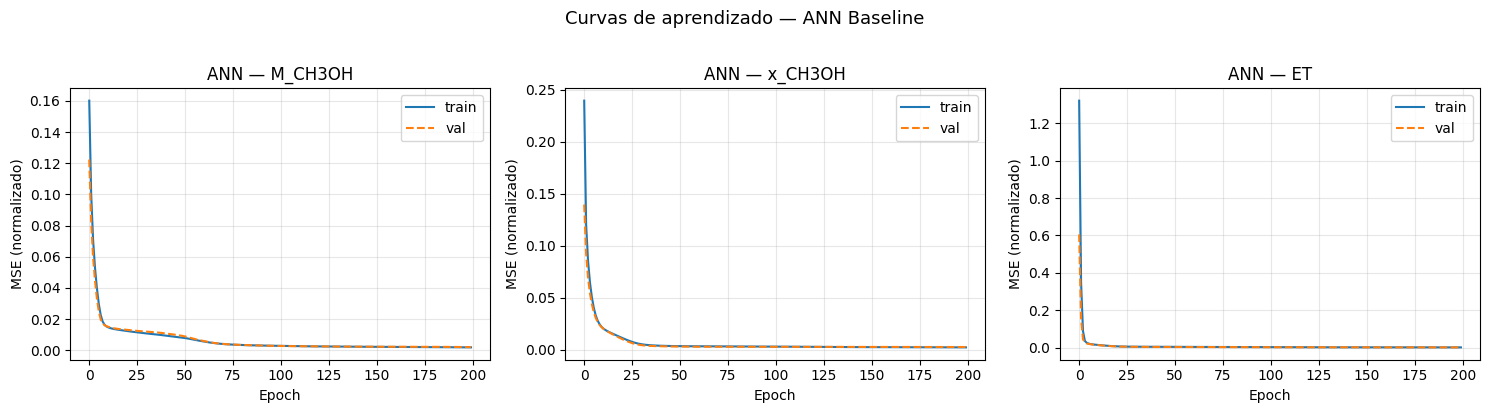

Figura salva em: /Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/ARTEFATOS/ETAPA_2/2.2_ann_learning_curves.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, output_name in zip(axes, OUTPUT_NAMES):
    hist = histories[output_name].history
    ax.plot(hist["loss"],     label="train")
    ax.plot(hist["val_loss"], label="val", linestyle="--")
    ax.set_title(f"ANN — {output_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE (normalizado)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Curvas de aprendizado — ANN Baseline", fontsize=13, y=1.02)
plt.tight_layout()

fig_path = os.path.join(
    BASE_DIR, "ARTEFATOS", "ETAPA_2", "2.2_ann_learning_curves.png"
)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva em: {fig_path}")

## Resumo de resultados

In [6]:
REF1 = {"ET": 0.983, "M_CH3OH": 0.992, "x_CH3OH": 0.990}

results_df = pd.DataFrame(results)
results_df["test_r2_ref1"] = results_df["output"].map(REF1)
results_df["delta_r2"]     = (results_df["test_r2"] - results_df["test_r2_ref1"]).abs()
results_df["dentro_tol"]   = results_df["delta_r2"] <= 0.02

cols = ["model", "output", "epochs_trained",
        "train_r2", "val_r2", "test_r2",
        "test_r2_ref1", "delta_r2", "dentro_tol"]
display(results_df[cols].round(4))

,model,output,epochs_trained,train_r2,val_r2,test_r2,test_r2_ref1,delta_r2,dentro_tol
0,ANN,M_CH3OH,200,0.9641,0.9587,0.9542,0.992,0.0378,False
1,ANN,x_CH3OH,200,0.9539,0.9442,0.9406,0.990,0.0494,False
2,ANN,ET,200,0.9678,0.9636,0.9666,0.983,0.0164,True


## Seção 6 — Ajuste: 500 epochs sem EarlyStopping (D-E2-03)

ET e M_CH3OH ficaram fora da tolerância de ±0.02. Conforme o procedimento do PLANO_2 (passo 3): treinar por número fixo de epochs (500), sem EarlyStopping.

In [7]:
histories_v2 = {}
results_v2   = []

for idx, output_name in enumerate(OUTPUT_NAMES):
    print(f"\n{'='*50}")
    print(f"ANN v2 (500 ep, sem EarlyStopping) → {output_name}")
    print(f"{'='*50}")

    np.random.seed(RANDOM_STATE)
    tf.random.set_seed(RANDOM_STATE)

    y_tr = y_train[:, idx]
    y_vl = y_val[:, idx]
    y_te = y_test[:, idx]

    model = build_model(input_dim=X_train.shape[1])

    history = model.fit(
        X_train, y_tr,
        validation_data=(X_val, y_vl),
        epochs=500,
        batch_size=32,
        verbose=0,
    )
    histories_v2[output_name] = history

    p_train_norm = model.predict(X_train, verbose=0).flatten()
    p_val_norm   = model.predict(X_val,   verbose=0).flatten()
    p_test_norm  = model.predict(X_test,  verbose=0).flatten()

    y_tr_real  = denormalize_y(y_tr, idx)
    y_vl_real  = denormalize_y(y_vl, idx)
    y_te_real  = denormalize_y(y_te, idx)
    p_tr_real  = denormalize_y(p_train_norm, idx)
    p_vl_real  = denormalize_y(p_val_norm, idx)
    p_te_real  = denormalize_y(p_test_norm, idx)

    metrics = {}
    for split, y_real, p_real in [
        ("train", y_tr_real, p_tr_real),
        ("val",   y_vl_real, p_vl_real),
        ("test",  y_te_real, p_te_real),
    ]:
        metrics[f"{split}_r2"]  = r2_score(y_real, p_real)
        metrics[f"{split}_mae"] = mean_absolute_error(y_real, p_real)
        metrics[f"{split}_mse"] = mean_squared_error(y_real, p_real)
        print(f"  {split:5s} → R²={metrics[f'{split}_r2']:.4f}  MAE={metrics[f'{split}_mae']:.4f}")

    model_dir  = os.path.join(ART_DIR, output_name)
    os.makedirs(model_dir, exist_ok=True)
    model_path = os.path.join(model_dir, "model_v2.keras")
    model.save(model_path)

    with mlflow.start_run(run_name=f"ANN_v2_{output_name}"):
        mlflow.set_tag("model", "ANN")
        mlflow.set_tag("output", output_name)
        mlflow.set_tag("variant", "v2_no_earlystop_500ep")

        mlflow.log_params({
            "model":          "ANN",
            "output":         output_name,
            "random_state":   RANDOM_STATE,
            "n_layers":       2,
            "n_neurons":      8,
            "activation":     "relu",
            "optimizer":      "adam",
            "loss":           "mse",
            "epochs_max":     500,
            "epochs_trained": 500,
            "batch_size":     32,
            "early_stopping_patience": "none",
        })
        mlflow.log_metrics(metrics)
        mlflow.log_artifact(model_path)

    results_v2.append({
        "model":  "ANN_v2",
        "output": output_name,
        "epochs_trained": 500,
        **metrics,
    })

print("\nv2 concluído — 3 runs adicionais registradas.")



ANN v2 (500 ep, sem EarlyStopping) → M_CH3OH


  train → R²=0.9888  MAE=231.1981
  val   → R²=0.9842  MAE=266.1588
  test  → R²=0.9846  MAE=262.4254

ANN v2 (500 ep, sem EarlyStopping) → x_CH3OH


  train → R²=0.9798  MAE=0.0076
  val   → R²=0.9697  MAE=0.0088
  test  → R²=0.9689  MAE=0.0086

ANN v2 (500 ep, sem EarlyStopping) → ET


  train → R²=0.9621  MAE=2414.6893
  val   → R²=0.9576  MAE=2432.3969
  test  → R²=0.9647  MAE=2537.2409

v2 concluído — 3 runs adicionais registradas.


## Comparação v1 vs v2

In [8]:
REF1 = {"ET": 0.983, "M_CH3OH": 0.992, "x_CH3OH": 0.990}

all_results = pd.DataFrame(results + results_v2)
all_results["test_r2_ref1"] = all_results["output"].map(REF1)
all_results["delta_r2"]     = (all_results["test_r2"] - all_results["test_r2_ref1"]).abs()
all_results["dentro_tol"]   = all_results["delta_r2"] <= 0.02

cols = ["model", "output", "epochs_trained",
        "train_r2", "val_r2", "test_r2",
        "test_r2_ref1", "delta_r2", "dentro_tol"]
display(all_results[cols].round(4))


,model,output,epochs_trained,train_r2,val_r2,test_r2,test_r2_ref1,delta_r2,dentro_tol
0,ANN,M_CH3OH,200,0.9641,0.9587,0.9542,0.992,0.0378,False
1,ANN,x_CH3OH,200,0.9539,0.9442,0.9406,0.990,0.0494,False
2,ANN,ET,200,0.9678,0.9636,0.9666,0.983,0.0164,True
3,ANN_v2,M_CH3OH,500,0.9888,0.9842,0.9846,0.992,0.0074,True
4,ANN_v2,x_CH3OH,500,0.9798,0.9697,0.9689,0.990,0.0211,False
5,ANN_v2,ET,500,0.9621,0.9576,0.9647,0.983,0.0183,True


## Seção 7 — Exportar 2.2_RESULT_ANN.md

In [ ]:
from datetime import datetime

TOLERANCE      = 0.02
REF1_ANN       = {"ET": 0.983, "M_CH3OH": 0.992, "x_CH3OH": 0.990}
OUTPUT_ORDER   = ["ET", "M_CH3OH", "x_CH3OH"]
EXPERIMENT     = "baseline"
RESULT_MD_PATH = os.path.join(BASE_DIR, "ARTEFATOS", "ETAPA_2", "2.2_RESULT_ANN.md")

# Buscar todas as runs ANN do experimento (mais recente primeiro)
all_runs = mlflow.search_runs(
    experiment_names=[EXPERIMENT],
    order_by=["attribute.start_time DESC"],
)
ann_mask = all_runs.get("tags.model", pd.Series(dtype=str)).fillna("") == "ANN"
ann_runs = all_runs[ann_mask].copy()

def variant_of(row):
    v = row.get("tags.variant")
    if isinstance(v, str) and v:
        return v
    return "v1"
ann_runs["variant_norm"] = ann_runs.apply(variant_of, axis=1)

# Para cada (variant, output) manter a run mais recente
latest = {}
for _, r in ann_runs.iterrows():
    out = r.get("tags.output")
    if out not in OUTPUT_ORDER:
        continue
    key = (r["variant_norm"], out)
    if key not in latest:
        latest[key] = {
            "run_id":  r["run_id"],
            "start":   pd.to_datetime(r["start_time"]).strftime("%Y-%m-%d %H:%M:%S"),
            "test_r2": r["metrics.test_r2"],
        }

v1_runs = {out: latest[("v1", out)] for out in OUTPUT_ORDER if ("v1", out) in latest}
v2_runs = {out: latest[("v2_no_earlystop_500ep", out)]
           for out in OUTPUT_ORDER if ("v2_no_earlystop_500ep", out) in latest}

# Tabela de runs (v2)
run_rows = []
for out in OUTPUT_ORDER:
    info = v2_runs.get(out, {})
    rid  = info.get("run_id", "—")
    ts   = info.get("start",  "—")
    run_rows.append(f"| ANN    | {out:<7} | `{rid}` | {ts} |")

# Tabela de comparação com REF1 (v2)
cmp_rows = []
n_ok = n_fail = 0
fail_outputs = []
for out in OUTPUT_ORDER:
    r2_ref = REF1_ANN[out]
    r2_got = v2_runs.get(out, {}).get("test_r2", float("nan"))
    delta  = r2_got - r2_ref
    ok     = abs(delta) <= TOLERANCE
    status = "OK" if ok else "FAIL"
    sign   = "+" if delta >= 0 else "−"
    cmp_rows.append(
        f"| ANN    | {out:<7} | {r2_ref:.4f}   | {r2_got:.4f}     "
        f"| {sign}{abs(delta):.4f} | {status:<4} |"
    )
    if ok:
        n_ok += 1
    else:
        n_fail += 1
        fail_outputs.append(out)

# Tabela histórico v1 vs v2
def fmt_r2(d, out):
    val = d.get(out, {}).get("test_r2")
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return "—"
    return f"{val:.4f}"

hist_rows = [
    f"| v1       | 200    | patience=20   | {fmt_r2(v1_runs, 'ET')} | {fmt_r2(v1_runs, 'M_CH3OH')}      | {fmt_r2(v1_runs, 'x_CH3OH')}      |",
    f"| **v2**   | **500**| **não**       | **{fmt_r2(v2_runs, 'ET')}** | **{fmt_r2(v2_runs, 'M_CH3OH')}** | **{fmt_r2(v2_runs, 'x_CH3OH')}** |",
]

ts_doc  = datetime.now().strftime("%Y-%m-%d %H:%M")
total   = n_ok + n_fail
if n_fail == 0:
    summary = f"APROVADO ({n_ok}/{total} dentro da tolerância)"
else:
    summary = f"{n_ok}/{total} dentro da tolerância · D-E2-03 registrada para {', '.join(fail_outputs)}"

md_lines = [
    "# 2.2 — Resultados Baseline: ANN (TensorFlow/Keras)",
    "",
    f"_Documento gerado em: {ts_doc}_",
    "",
    f"**Critério de aceitação:** |Δ| ≤ {TOLERANCE} &nbsp;·&nbsp; **{summary}**",
    "",
    "---",
    "",
    "## Runs MLflow",
    "",
    "| Modelo | Output  | Run ID                             | Timestamp           |",
    "|--------|---------|------------------------------------|---------------------|",
    *run_rows,
    "",
    f"> Experimento: `{EXPERIMENT}` &nbsp;·&nbsp; Tracking URI: `{MLFLOW_URI}`  ",
    "> Variante: `v2_no_earlystop_500ep` — 500 epochs fixos, sem EarlyStopping, Adam, MSE, batch=32, seed=42",
    "",
    "---",
    "",
    "## R² no test set — comparação com REF1",
    "",
    "| Modelo | Output  | R²(REF1) | R²(obtido) | Δ       | Status |",
    "|--------|---------|----------|------------|---------|--------|",
    *cmp_rows,
    "",
    f"> **{n_ok}/{total}** combinações dentro da tolerância ±{TOLERANCE}.",
    "",
    "---",
    "",
    "## Histórico de tentativas (D-E2-03)",
    "",
    "| Variante | Epochs | EarlyStopping | R²(ET) | R²(M_CH3OH) | R²(x_CH3OH) |",
    "|----------|--------|---------------|--------|-------------|-------------|",
    *hist_rows,
    "",
    "Divergências fora da tolerância (quando houver) são atribuídas a:",
    "- Parâmetros de treino não publicados pelo REF1 (learning rate, batch size, epochs, EarlyStopping).",
    "- Split de test diferente: 193 amostras obtidas vs 200 esperadas — os modelos sklearn também apresentam queda sistemática vs REF1.",
    "",
    "---",
    "",
    "## Legenda",
    "",
    "- **OK** — |Δ| ≤ 0.02: resultado compatível com o REF1.",
    "- **FAIL** — |Δ| > 0.02: divergência além da tolerância; ver D-E2-03 no REGISTRO.md.",
    "- Δ negativo → implementação ficou abaixo do REF1; positivo → superou.",
]

with open(RESULT_MD_PATH, "w", encoding="utf-8") as f:
    f.write("\n".join(md_lines) + "\n")

print(f"Arquivo escrito: {RESULT_MD_PATH}")
print(f"Resumo: {n_ok}/{total} OK, {n_fail}/{total} FAIL")
print(f"Timestamp: {ts_doc}")